<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/graviationalwave_GW150914.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Graviational Wave GW150914**

The signal was named GW150914 (from gravitational wave and the date of observation 2015-09-14). It was also the first observation of a binary black hole merger.

https://arxiv.org/abs/1602.03839

https://en.m.wikipedia.org/wiki/First_observation_of_gravitational_waves

In [49]:
# gwpy and h5py for LIGOs HDF5 data
!pip install h5py gwpy ja gwosc PyWavelets matplotlib -q
import numpy as np
from gwpy.timeseries import TimeSeries
from gwosc import datasets # gwosc provides access to all detected events
from gwpy.plot import Plot
import matplotlib.pyplot as plt

In [50]:
# List all available events of gravitational waves
events = datasets.find_datasets(type="event")
print(f"Available events: {events}")

Available events: ['151008-v1', '151012.2-v1', '151116-v1', '161202-v1', '161217-v1', '170208-v1', '170219-v1', '170405-v1', '170412-v1', '170423-v1', '170616-v1', '170630-v1', '170705-v1', '170720-v1', '190924_232654-v1', '191118_212859-v1', '191223_014159-v1', '191225_215715-v1', '200114_020818-v1', '200121_031748-v1', '200201_203549-v1', '200214_224526-v1', '200214_224526-v2', '200219_201407-v1', '200311_103121-v1', 'GRB051103-v1', 'GW150914-v1', 'GW150914-v2', 'GW150914-v3', 'GW151012-v1', 'GW151012-v2', 'GW151012-v3', 'GW151226-v1', 'GW151226-v2', 'GW170104-v1', 'GW170104-v2', 'GW170608-v1', 'GW170608-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v1', 'GW170814-v2', 'GW170814-v3', 'GW170817-v1', 'GW170817-v2', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1', 'GW190403_051519-v1', 'GW190408_181802-v1', 'GW190408_181802-v2', 'GW190412-v1', 'GW190412-v2', 'GW190412-v3', 'GW190412_053044-v4', 'GW190413_052954-v1', 'GW190413_052954-v2', 'GW190413_134308-v1', 'GW190413_134308-

For example see [Marginal candidates from "GWTC-1](https://gwosc.org/eventapi/html/GWTC-1-marginal/)

In [65]:
# Select one gravitational event
#event = 'GW170608' #; time = 1180922494.5
#event = 'GW170814' #; time = 1186741861.5
event = 'GW150914' #; time = 1126259462

In [66]:
# Get GPS time for a specific event
time = datasets.event_gps(event)
print(f"GPS Time for {event}: {time}")

GPS Time for GW150914: 1126259462.4


In [67]:
# Fetch LIGO data for GW150914 event
def load_ligo_data(event=event, detector='H1', duration=32):
    # Start time of the event (GPS timestamp)
    event_time = time  # event time in GPS seconds

    # Fetch the strain data around event
    start_time = event_time - duration // 2
    end_time = event_time + duration // 2

    # Fetch strain data for a specific detector (H1 or L1)
    data = TimeSeries.fetch_open_data(detector, start_time, end_time, cache=True)
    return data

# Load strain data for Hanford (H1) and Livingston (L1) detectors
h1_data = load_ligo_data(event=event, detector='H1')
l1_data = load_ligo_data(event=event, detector='L1')

print("Hanford Data (H1):", h1_data)
print("Livingston Data (L1):", l1_data)

Hanford Data (H1): TimeSeries([ 4.11628029e-19,  3.96443979e-19,  3.38344656e-19,
            ..., -6.44526154e-21, -6.36026905e-21,
            -3.74912730e-20]
           unit: dimensionless,
           t0: 1126259446.3999023 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
Livingston Data (L1): TimeSeries([-9.57782180e-19, -9.44008859e-19, -9.68975657e-19,
            ..., -7.18181209e-19, -7.29759972e-19,
            -7.35275811e-19]
           unit: dimensionless,
           t0: 1126259446.3999023 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


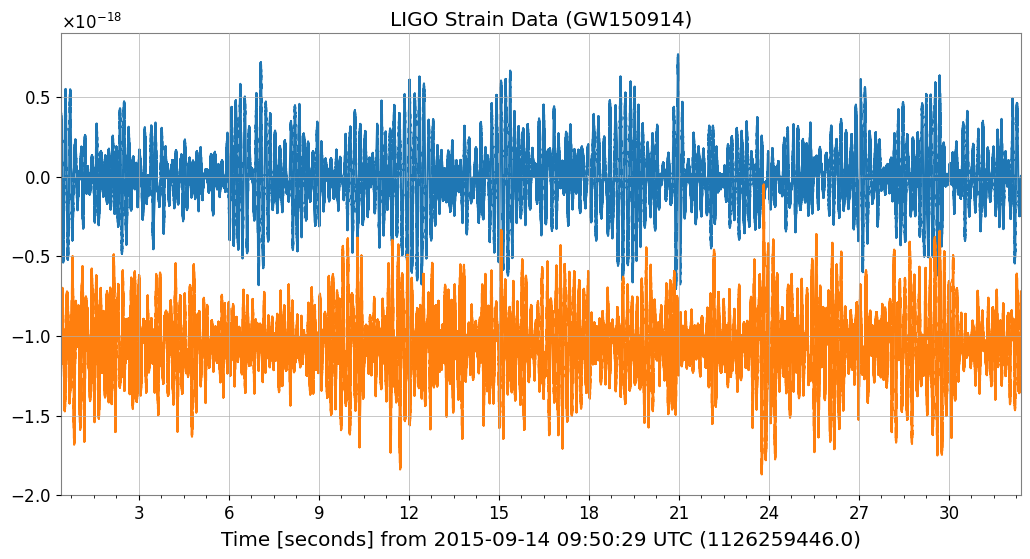

In [68]:
# Plot raw strain data for Hanford (H1) and Livingston (L1)
plot = Plot(h1_data, l1_data, title=f"LIGO Strain Data ({event})")
plot.show()

In [69]:
print("Hanford Data Summary:")
print(f"Start Time: {h1_data.times.value[0]} GPS seconds")
print(f"End Time: {h1_data.times.value[-1]} GPS seconds")
print(f"Sampling Rate: {h1_data.sample_rate} Hz")
print(f"Duration: {h1_data.duration.value} seconds")
print(f"Data Units: {h1_data.unit}")

print("\nLivingston Data Summary:")
print(f"Start Time: {l1_data.times.value[0]} GPS seconds")
print(f"End Time: {l1_data.times.value[-1]} GPS seconds")
print(f"Sampling Rate: {l1_data.sample_rate} Hz")
print(f"Duration: {l1_data.duration.value} seconds")
print(f"Data Units: {l1_data.unit}")

Hanford Data Summary:
Start Time: 1126259446.3999023 GPS seconds
End Time: 1126259478.3996582 GPS seconds
Sampling Rate: 4096.0 Hz Hz
Duration: 32.0 seconds
Data Units: 

Livingston Data Summary:
Start Time: 1126259446.3999023 GPS seconds
End Time: 1126259478.3996582 GPS seconds
Sampling Rate: 4096.0 Hz Hz
Duration: 32.0 seconds
Data Units: 


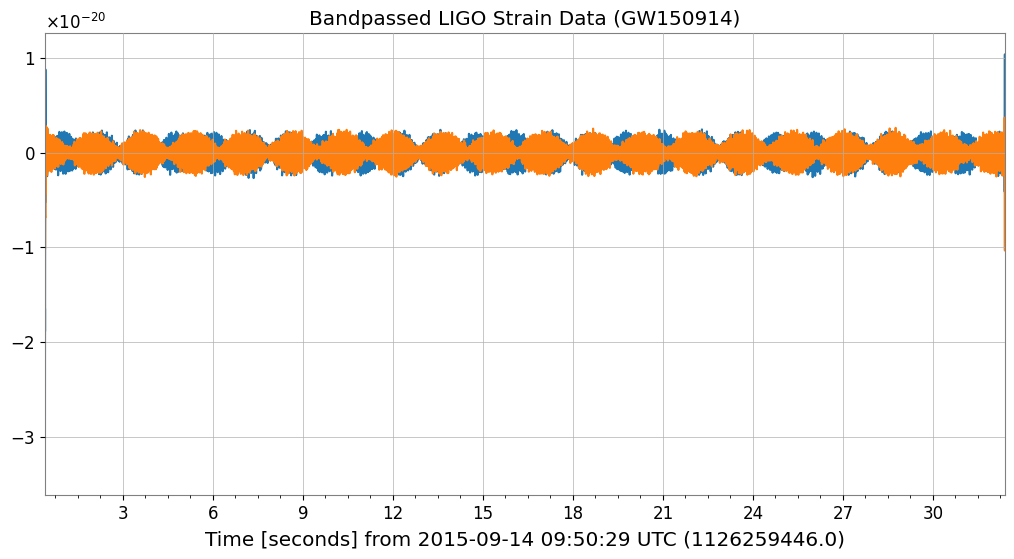

In [70]:
# Apply a bandpass filter between 30 Hz and 300 Hz
# Gravitational wave signals in frequency between 30-300 Hz
# Remove unwanted low abd high fequency
h1_data_bp = h1_data.bandpass(30, 300)
l1_data_bp = l1_data.bandpass(30, 300)

# Plot bandpassed data
plot = Plot(h1_data_bp, l1_data_bp, title=f"Bandpassed LIGO Strain Data ({event})")
plot.show()

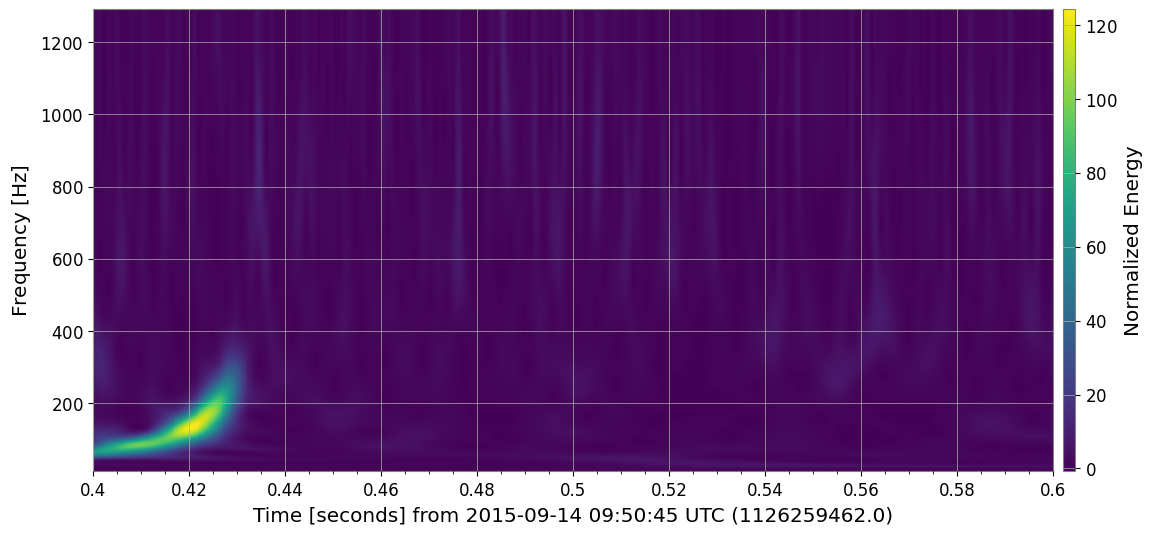

In [71]:
# Apply whitening to strain data. Makes noise spectrum flat across frequencies. Enhances gravitational wave signal
h1_data_white = h1_data_bp.whiten()
l1_data_white = l1_data_bp.whiten()
#plot = Plot(h1_data_white, l1_data_white, title=f"Whitened LIGO Strain Data ({event})")

# Generate a Q-transform plot of whitened data
# Time frequency viszalisation (q transform) for short duratiom signals
q_transform_h1 = h1_data_white.q_transform(outseg=(time, time + 0.2))

# Plot Q-transform (time-frequency representation)
plot = q_transform_h1.plot()
plot.colorbar(label="Normalized Energy")
plot.show()

**Other stuff**

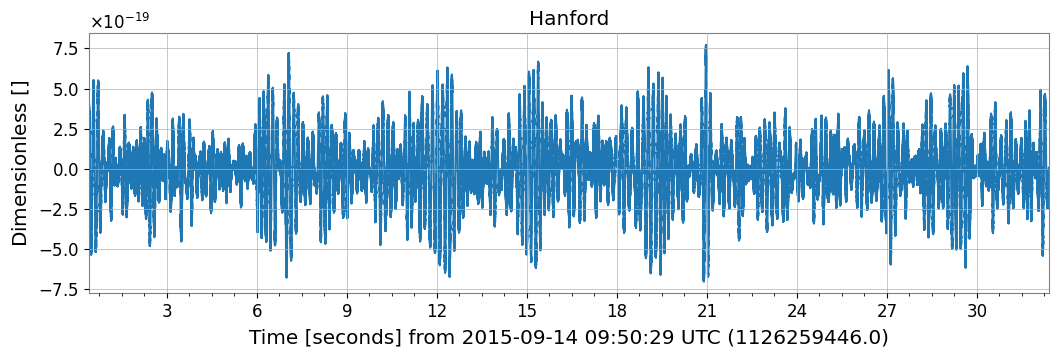

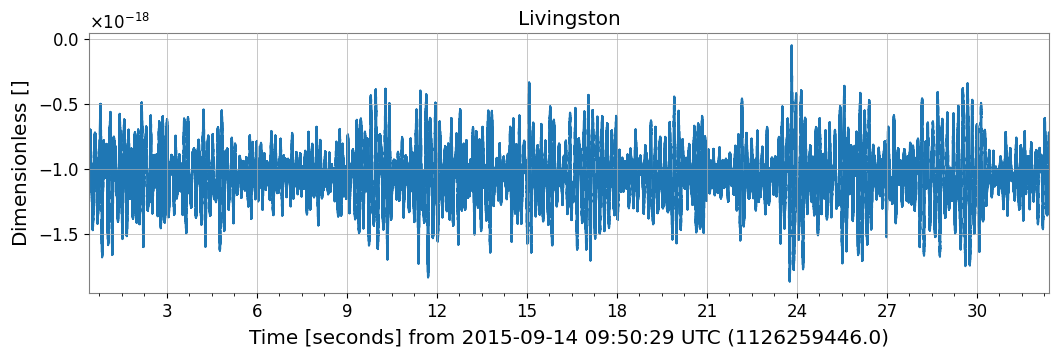

In [72]:
# Load strain data for Hanford, Livingston, and Virgo detectors
hanford_data = TimeSeries.fetch_open_data('H1', time - 16, time + 16, cache=True)
livingston_data = TimeSeries.fetch_open_data('L1', time - 16, time + 16, cache=True)

plot_h1a = hanford_data.plot(title='Hanford')
plt.show()

plot_l1a = livingston_data.plot(title='Livingston')
plt.show()

In [73]:
# Apply a bandpass filter between 30 and 400 Hz to remove noise outside this range
hanford_data_bp = hanford_data.bandpass(30, 400)
livingston_data_bp = livingston_data.bandpass(30, 400)

# Whiten the data to make the noise spectrum flat across frequencies
hanford_data_white = hanford_data_bp.whiten()
livingston_data_white = livingston_data_bp.whiten()

# Generate a Q-transform plot of the whitened data around the event time
q_transform_h1 = hanford_data_white.q_transform(outseg=(time-0.2, time + 0.2))
q_transform_l1 = livingston_data_white.q_transform(outseg=(time-0.2, time + 0.2))

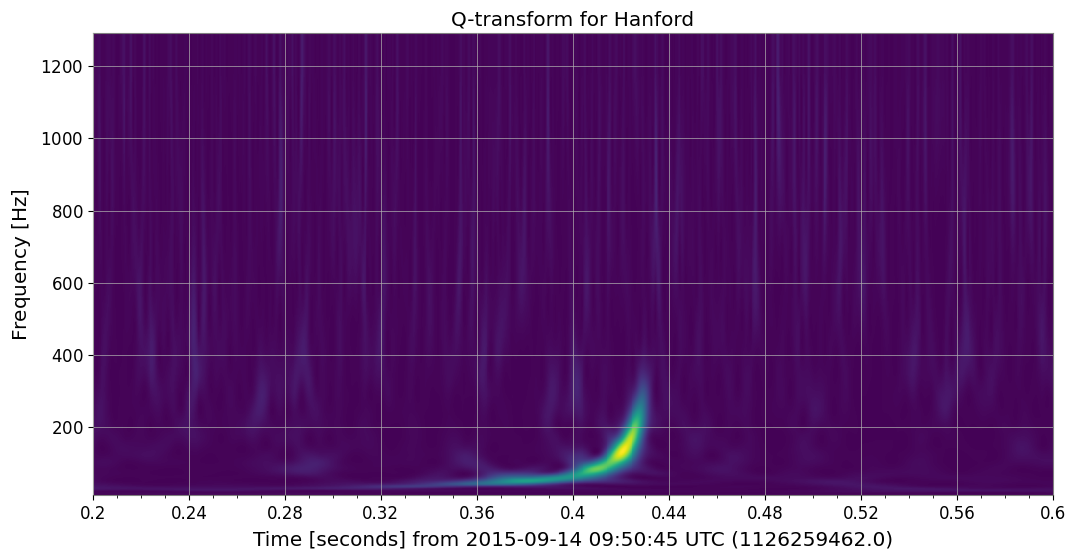

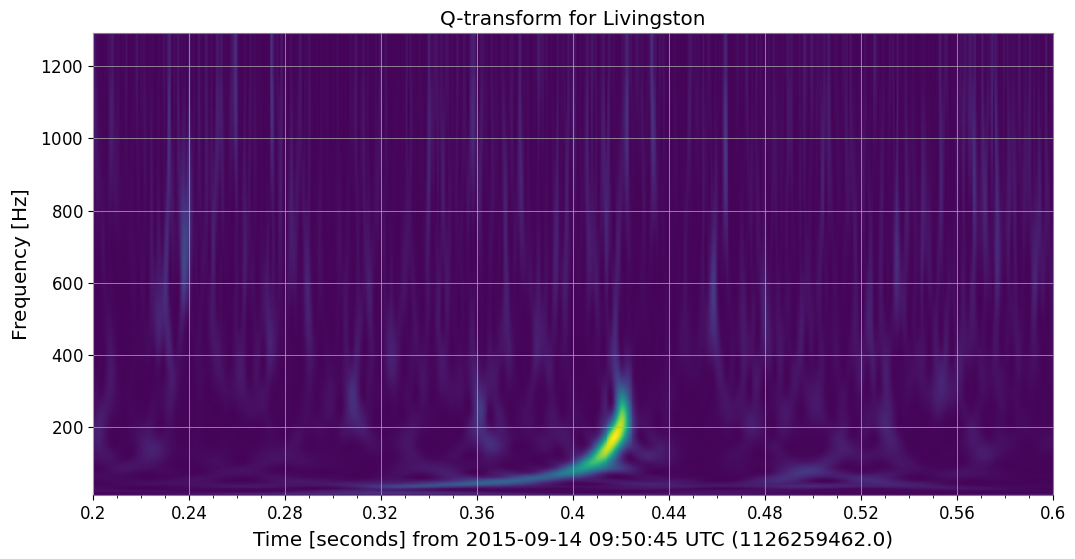

In [74]:
# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot(title='Q-transform for Hanford')
plt.show()

# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot(title='Q-transform for Livingston')
plt.show()

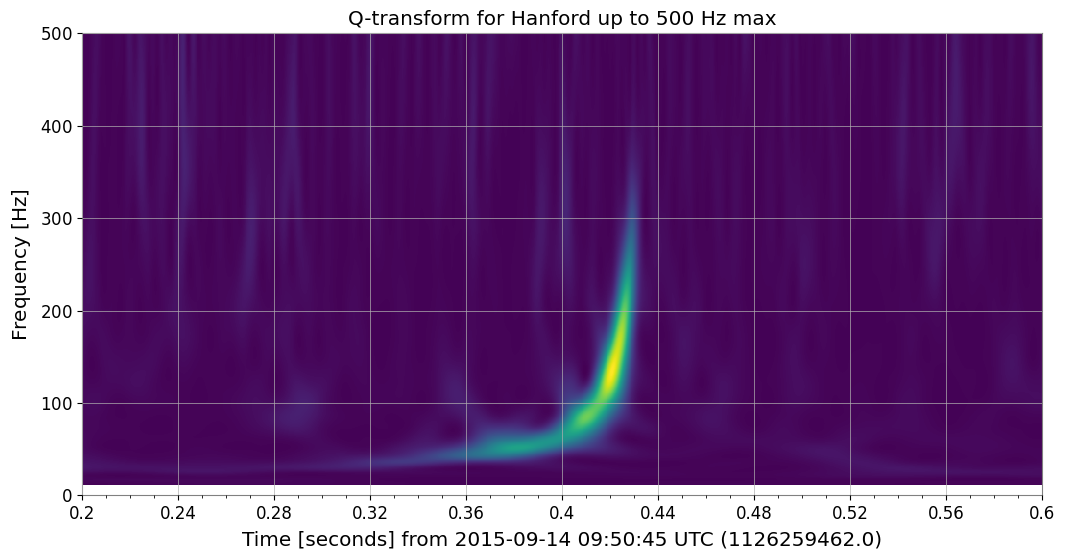

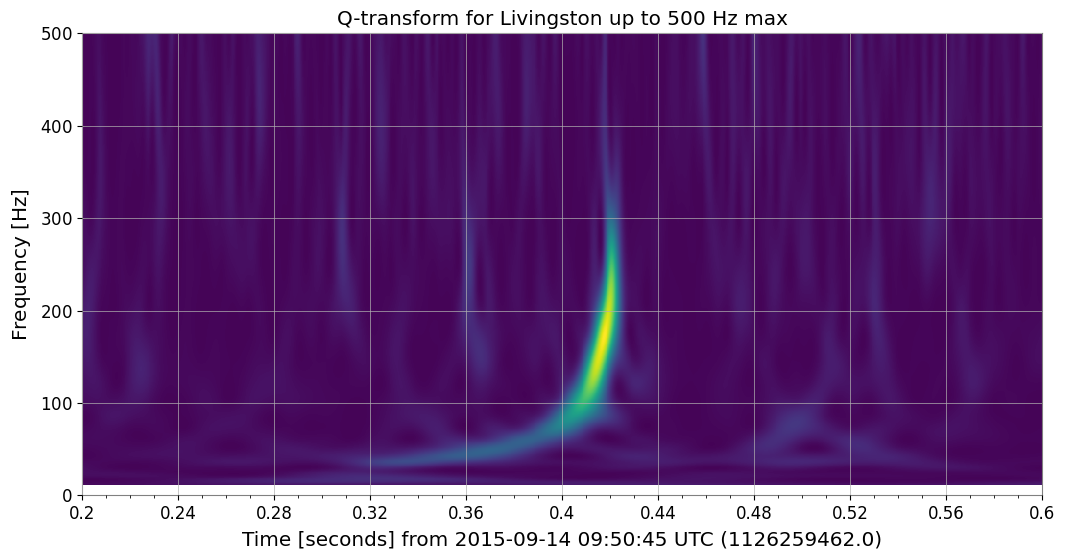

In [75]:
# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot(title='Q-transform for Hanford up to 500 Hz max')
plt.ylim(0, 500)
plt.show()

# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot(title='Q-transform for Livingston up to 500 Hz max')
plt.ylim(0, 500)
plt.show()